In [2]:
# %% [markdown]
# # Data Exploration (EDA) - Resume Dataset
# This notebook performs the initial Exploratory Data Analysis on `Resume.csv` for the AI Resume Screener project.

# %%
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

Dataset loaded successfully with 2484 rows and 4 columns.
=== GENERAL STATISTICS ===
Total Resumes: 2484
Total Unique Categories: 24

Resumes per Category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


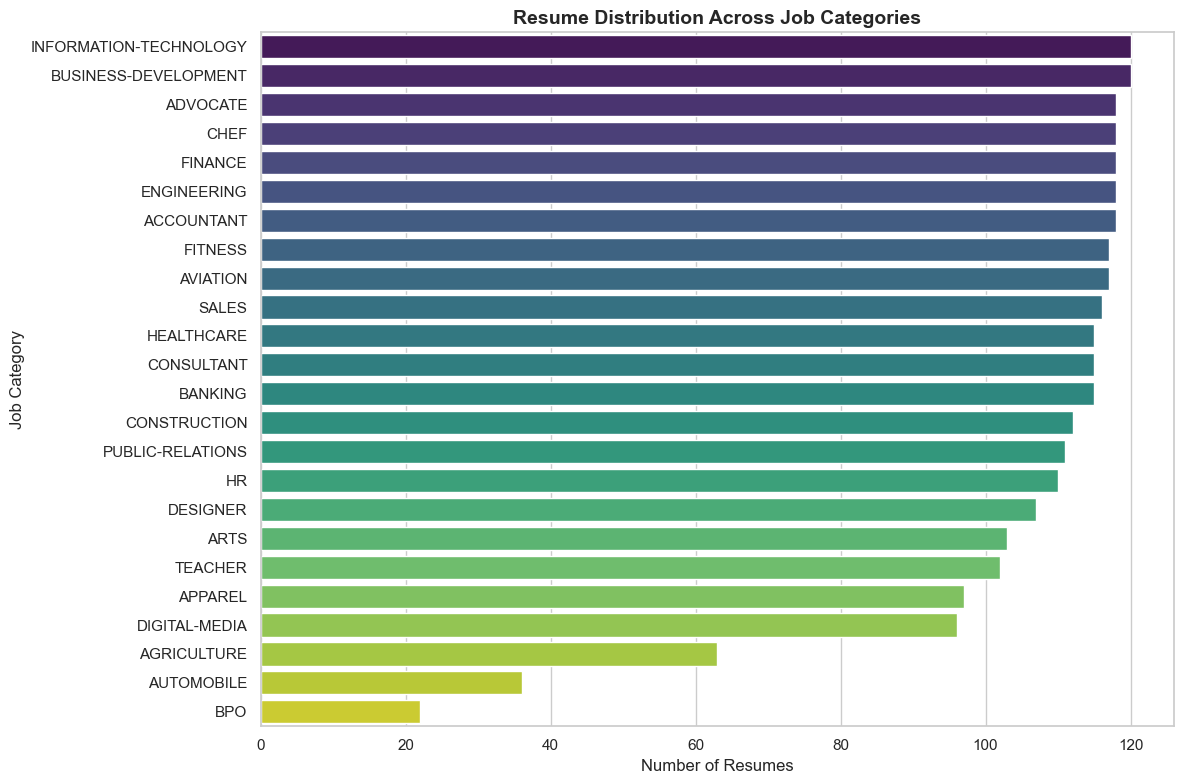

=== RESUME LENGTH STATISTICS ===
Average Resume Length: 811.33 words
Median Resume Length: 757.00 words


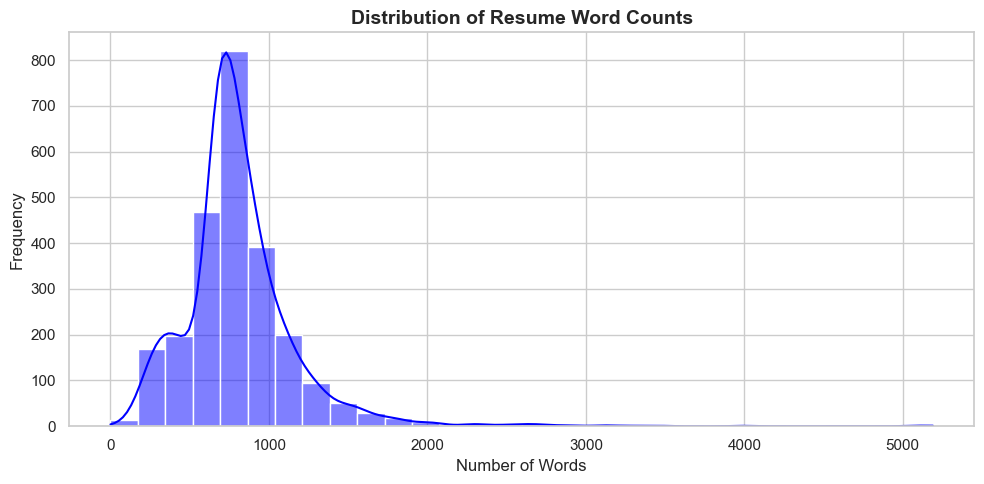

=== TOP 20 FREQUENT WORDS ===
sales: 8275
customer: 7927
business: 7866
new: 6407
service: 6223
team: 6073
development: 5731
training: 5637
project: 5362
manager: 4534
information: 4502
marketing: 4489
financial: 4227
office: 4186
support: 4122
education: 4093
including: 4045
staff: 3949
professional: 3857
data: 3797


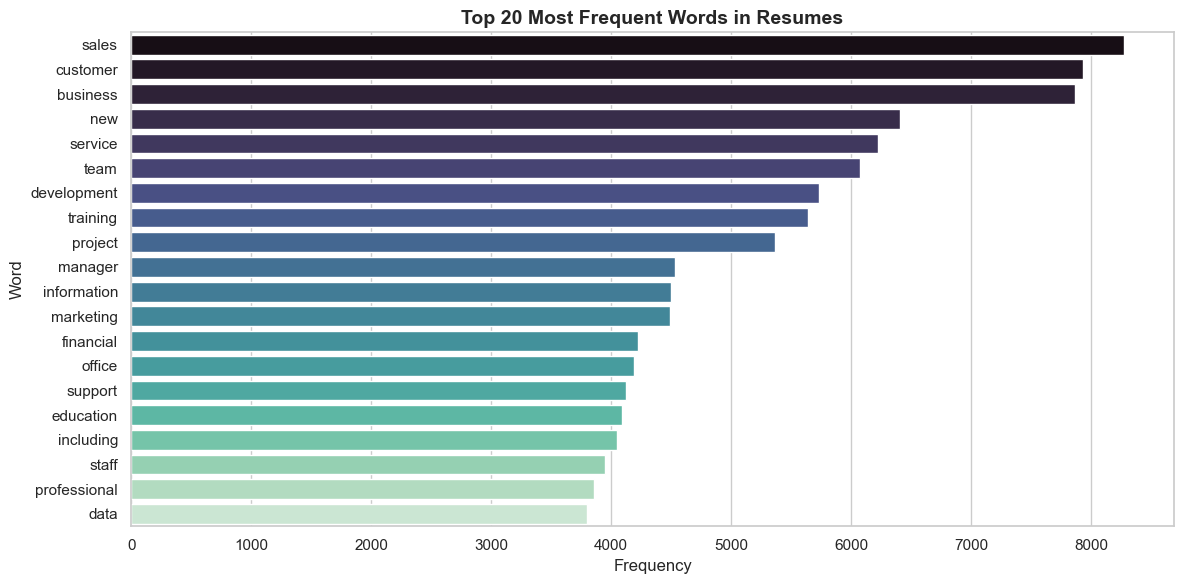

=== RANDOM RESUME SAMPLES ===

--------------------------------------------------------------------------------
Resume ID: 99244405 | Assigned Category: TEACHER
--------------------------------------------------------------------------------
Kpandipou Koffi Summary Compassionate teaching professional delivering exemplary support and assistance to teachers and students. Display exceptional Communication and problem solving skills. Experience in office administration and public speaking. Attentive and adaptable, skilled in management of c...

--------------------------------------------------------------------------------
Resume ID: 17562754 | Assigned Category: DIGITAL-MEDIA
--------------------------------------------------------------------------------
DIRECTOR OF DIGITAL TRANSFORMATION Executive Profile Digital and print media professional and consultant with a strong vision to develop new projects and specialist in business development. Strong management skills and leading teams. Re

In [11]:

# Set visual theme for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# %% [markdown]
# ## 1. Data Loading

# %%
# Load the dataset (adjust path depending on your project structure)
df = pd.read_csv("../data/raw/Resume.csv")

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

# %% [markdown]
# ## 2. General Statistics: Total Resumes & Categories

# %%
total_resumes = len(df)
total_categories = df["Category"].nunique()
category_distribution = df["Category"].value_counts().sort_values(ascending=False)

print("=== GENERAL STATISTICS ===")
print(f"Total Resumes: {total_resumes}")
print(f"Total Unique Categories: {total_categories}")
print("\nResumes per Category:")
print(category_distribution)

# %% [markdown]
# ## 3. Visualization: Category Distribution

# %%
plt.rcParams["figure.figsize"] = (12, 8)
sns.barplot(
    x=category_distribution.values, 
    y=category_distribution.index, 
    hue=category_distribution.index,  
    legend=False,                     
    palette="viridis"
)
plt.title("Resume Distribution Across Job Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Resumes", fontsize=12)
plt.ylabel("Job Category", fontsize=12)
plt.tight_layout()
plt.savefig("./distributions/category_distribution.png")
plt.show()

# %% [markdown]
# ## 4. Average Resume Length in Words

# %%
# Compute word count by splitting strings by whitespace
df["Word_Count"] = df["Resume_str"].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

mean_word_count = df["Word_Count"].mean()
median_word_count = df["Word_Count"].median()

print("=== RESUME LENGTH STATISTICS ===")
print(f"Average Resume Length: {mean_word_count:.2f} words")
print(f"Median Resume Length: {median_word_count:.2f} words")

# Plot text length distribution
plt.rcParams["figure.figsize"] = (10, 5)
sns.histplot(df["Word_Count"], bins=30, kde=True, color="blue")
plt.title("Distribution of Resume Word Counts", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("./distributions/resume_length_distribution.png")
plt.show()

# %% [markdown]
# ## 5. Top 20 Most Frequent Words (Excluding Stopwords)

# %%
# Initialize base English stopwords
custom_stopwords = set(ENGLISH_STOP_WORDS)

# Append domain-specific structural/template noise found in this dataset
structural_noise = {
    "state",
    "city",
    "company",
    "name",
    "management",
    "experience",
    "skills",
    "work",
    "employee",
}
custom_stopwords = custom_stopwords.union(structural_noise)


def preprocess_and_tokenize(text):
    if pd.isna(text):
        return []
    # Extract lowercase alphabetic tokens with length >= 2
    tokens = re.findall(r"\b[a-zA-Z]{2,}\b", str(text).lower())
    # Filter out defined stopwords
    return [token for token in tokens if token not in custom_stopwords]

word_frequencies = Counter()

for text in df["Resume_str"]:
    resume_words = preprocess_and_tokenize(text)
    word_frequencies.update(resume_words)

# Extract top 20 most common words
top_20_words = word_frequencies.most_common(20)

print("=== TOP 20 FREQUENT WORDS ===")
for word, frequency in top_20_words:
    print(f"{word}: {frequency}")

# Plot top 20 words
words_df = pd.DataFrame(top_20_words, columns=["Word", "Frequency"])

words_df["Word"] = words_df["Word"].astype(str)
words_df["Frequency"] = words_df["Frequency"].astype(int)

plt.rcParams["figure.figsize"] = (12, 6)
sns.barplot(
    x="Frequency",
    y="Word",
    data=words_df,
    hue="Word", 
    legend=False,
    palette="mako",
)
plt.title("Top 20 Most Frequent Words in Resumes", fontsize=14, fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("./distributions/top_20_words.png")
plt.show()
# %% [markdown]
# ## 6. Sample Resumes Display

# %%
print("=== RANDOM RESUME SAMPLES ===\n")
# Sample 3 random rows for inspection (random_state ensures identical output on reruns)
resume_samples = df.sample(3, random_state=42)

for index, row in resume_samples.iterrows():
    print("-" * 80)
    print(f"Resume ID: {row['ID']} | Assigned Category: {row['Category']}")
    print("-" * 80)
    # Strip multiple whitespaces and newlines for a clean print output
    clean_preview = " ".join(row["Resume_str"].split())
    print(clean_preview[:300] + "...\n")